# 02 — Understand the synthetic market data

See which market inputs are needed to price the trading book.

Market data are valuation inputs, not Basel parameters. Curves, credit spreads, equity and commodity spots, foreign-exchange (FX) rates and implied volatilities describe the synthetic market.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

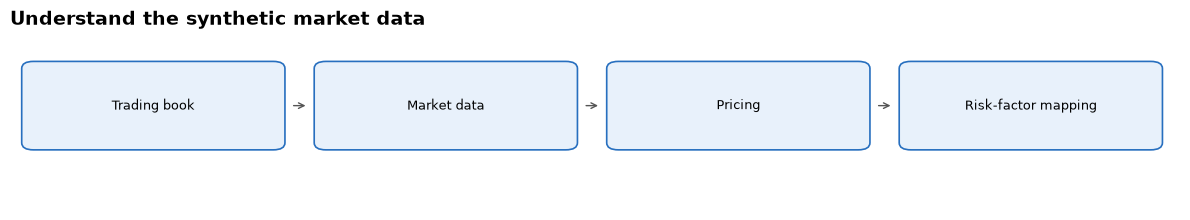

In [2]:
draw_flow(['Trading book', 'Market data', 'Pricing', 'Risk-factor mapping'],'Understand the synthetic market data',wrap_after=4)

Each trade requests its relevant inputs. A foreign bond uses its local rate curve, credit spread and FX rate to translate value into INR.

$$\text{INR value}=\text{local-currency value}\times\text{INR per unit of local currency}$$

In [3]:
market=yaml.safe_load((ROOT/'data/synthetic/market_data.yaml').read_text())
rows=[]
for group,values in market.items():
    if isinstance(values,dict):
        for key,value in values.items():
            if isinstance(value,dict):
                for tenor,amount in value.items(): rows.append([group,key,tenor,amount])
            else: rows.append([group,key,'',value])
inputs=pd.DataFrame(rows,columns=['market_group','risk_factor','tenor','value'])
display_sample(inputs,40)
rates=inputs[inputs.market_group=='rates'].copy()
rates['tenor_number']=pd.to_numeric(rates.tenor)

Displayed rows: first 40 of 67 observations, in table order.


,market_group,risk_factor,tenor,value
0,rates,INR,0.2500,0.0620
1,rates,INR,0.5000,0.0630
2,rates,INR,1.0000,0.0640
3,rates,INR,2.0000,0.0650
4,rates,INR,3.0000,0.0660
5,rates,INR,5.0000,0.0670
6,rates,INR,10.0000,0.0690
7,rates,INR,15.0000,0.0700
8,rates,INR,20.0000,0.0710
9,rates,INR,30.0000,0.0720


The visual below uses the calculated rows shown above.

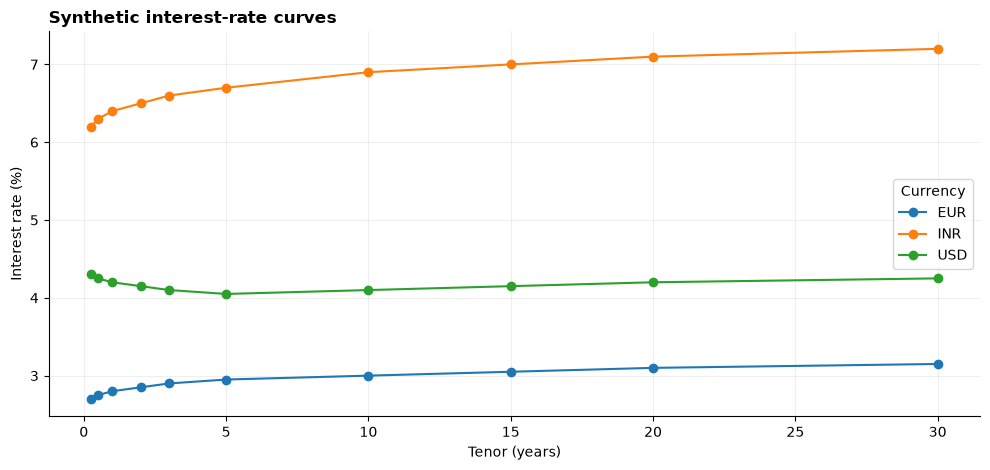

In [4]:
for currency,data in rates.groupby('risk_factor'):
    plt.plot(data.tenor_number,data.value*100,marker='o',label=currency)
plt.title('Synthetic interest-rate curves',loc='left',weight='bold')
plt.xlabel('Tenor (years)'); plt.ylabel('Interest rate (%)'); plt.legend(title='Currency')
plt.tight_layout(); plt.show()

These inputs generate economic prices; regulatory weights remain separately configured.